# Teste de Conhecimento
## Aluno: Rafael Bernado Cunha Oliveira
## Disciplina: Inteligência Artificial

## Etapa 1 — Carregar os dados

In [15]:
import pandas as pd

df = pd.read_csv("base_credito.csv")

df.head()

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54


## Etapa 2 – Conhecer os dados

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade                 50000 non-null  int64  
 1   renda_mensal          50000 non-null  float64
 2   score_credito         50000 non-null  int64  
 3   historico_pagamentos  50000 non-null  float64
 4   valor_emprestimo      50000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 1.9 MB


In [17]:
df.dtypes

,0
idade,int64
renda_mensal,float64
score_credito,int64
historico_pagamentos,float64
valor_emprestimo,float64


- `idade`: idade do cliente, em anos.
- `renda_mensal`: renda mensal do cliente.
- `score_credito`: pontuação de crédito do cliente.
- `historico_pagamentos`: indicador do histórico de pagamentos do cliente.
- `valor_emprestimo`: valor de empréstimo aprovado, que será previsto pelo modelo.

As variáveis de entrada serão utilizadas pelo modelo para estimar `valor_emprestimo`.

## Etapa 3 – Analisar os dados


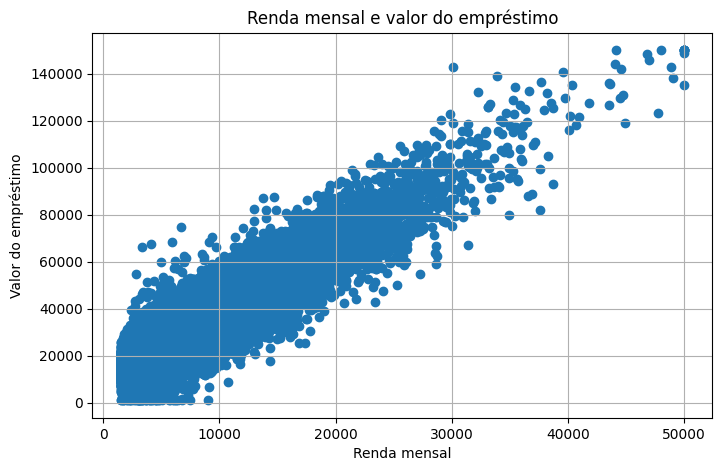

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["renda_mensal"], df["valor_emprestimo"])

plt.title("Renda mensal e valor do empréstimo")
plt.xlabel("Renda mensal")
plt.ylabel("Valor do empréstimo")
plt.grid(True)

plt.show()

### Análise
O gráfico indica uma relação positiva entre a renda mensal e o valor do empréstimo: de modo geral, clientes com maior renda tendem a apresentar valores de empréstimo maiores. Entretanto, existe dispersão nos dados, indicando que a renda não é o único fator relacionado ao valor concedido.

## Etapa 4 – Preparar os dados

In [21]:
from sklearn.model_selection import train_test_split

X = df[[
    "idade",
    "renda_mensal",
    "score_credito",
    "historico_pagamentos"
]]

y = df["valor_emprestimo"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Dados de treinamento:", X_treino.shape[0])
print("Dados de teste:", X_teste.shape[0])

Dados de treinamento: 40000
Dados de teste: 10000


## Etapa 5 – Treinar o modelo

In [22]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

modelo = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

modelo.fit(X_treino, y_treino)

previsoes = modelo.predict(X_teste)

## Etapa 6 – Avaliar o modelo

In [23]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_teste, previsoes)
r2 = r2_score(y_teste, previsoes)

print(f"Erro absoluto médio (MAE): R$ {mae:,.2f}")
print(f"R²: {r2:.4f}")

Erro absoluto médio (MAE): R$ 2,903.18
R²: 0.9266


### Interpretação das métricas

O **MAE (Erro Absoluto Médio)** representa, em média, o quanto as previsões do modelo se afastam dos valores reais. Nesse caso, o resultado indica que as previsões apresentam um erro médio de aproximadamente **R$ 2.903,18**.

O **R² (coeficiente de determinação)** indica quanto da variação dos valores de empréstimo é explicada pelo modelo. O valor obtido de aproximadamente **0,9266** indica que o modelo consegue explicar cerca de **92,66% da variação observada nos dados avaliados**.

## Etapa 7 – Comparar valores reais e previstos


In [24]:
comparacao = pd.DataFrame({
    "Valor real": y_teste.iloc[:10].values,
    "Valor previsto": previsoes[:10]
})

comparacao["Erro absoluto"] = abs(
    comparacao["Valor real"] - comparacao["Valor previsto"]
)

comparacao.round(2)

,Valor real,Valor previsto,Erro absoluto
0,22268.46,15891.04,6377.42
1,27457.59,29407.94,1950.35
2,25451.04,24320.05,1130.99
3,23890.67,21213.56,2677.11
4,27754.95,27915.54,160.59
5,12544.92,15497.42,2952.50
6,28759.01,27217.47,1541.54
7,46454.49,41291.74,5162.75
8,43199.01,36303.61,6895.40
9,34051.39,35575.70,1524.31


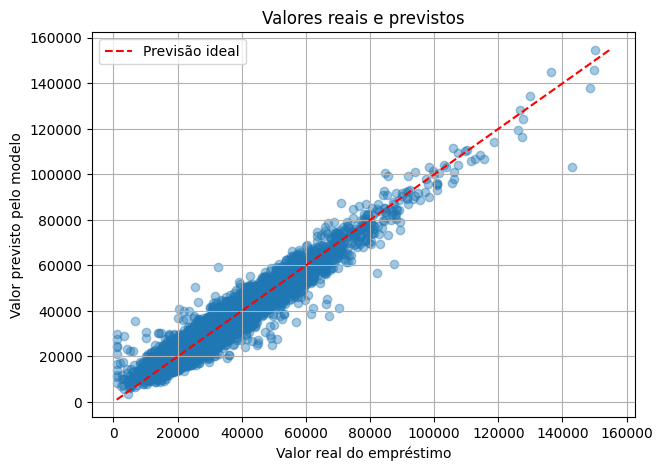

In [25]:
limite_min = min(y_teste.min(), previsoes.min())
limite_max = max(y_teste.max(), previsoes.max())

plt.figure(figsize=(7, 5))
plt.scatter(y_teste, previsoes, alpha=0.4)

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    color="red",
    linestyle="--",
    label="Previsão ideal"
)

plt.title("Valores reais e previstos")
plt.xlabel("Valor real do empréstimo")
plt.ylabel("Valor previsto pelo modelo")
plt.legend()
plt.grid(True)

plt.show()

### Interpretação

Os valores previstos pelo modelo ficaram, em geral, próximos dos valores reais. No gráfico, isso pode ser observado pela proximidade dos pontos em relação à linha de previsão ideal. Apesar disso, algumas previsões apresentam diferenças maiores, mostrando que o modelo não consegue prever todos os valores com a mesma precisão.

## Etapa 8 – Fazer uma previsão

In [26]:
novo_cliente = pd.DataFrame({
    "idade": [35],
    "renda_mensal": [8000.00],
    "score_credito": [700],
    "historico_pagamentos": [90.00]
})

valor_previsto = modelo.predict(novo_cliente)[0]

print("Características do novo cliente:")
display(novo_cliente)

print(f"Valor de empréstimo previsto: R$ {valor_previsto:,.2f}")

Características do novo cliente:


,idade,renda_mensal,score_credito,historico_pagamentos
0,35,8000.0,700,90.0


Valor de empréstimo previsto: R$ 36,716.66


### Interpretação

Para o novo cliente informado, o modelo estima um valor de empréstimo de **R$ 36.716,66**. Esse resultado é uma estimativa baseada nas características fornecidas ao modelo e não representa necessariamente o valor que seria aprovado pela instituição.

## Etapa 9 – Conclusão

O modelo apresentou um bom desempenho para estimar os valores dos empréstimos. O MAE foi de R$ 2.903,18, ou seja, em média, as previsões ficaram a essa distância dos valores reais. O R² foi de 0,9266, indicando que o modelo conseguiu explicar uma parte grande da variação nos valores dos empréstimos.

O gráfico também mostra um resultado positivo: a maioria dos pontos ficou próxima da linha de previsão ideal, então os valores previstos foram parecidos com os reais. Ainda assim, algumas previsões podem apresentar diferenças maiores.
Uma limitação é que o modelo considera apenas as informações disponíveis na base, como idade, renda, score de crédito e histórico de pagamentos.

Outros fatores que poderiam influenciar a concessão de crédito não foram incluídos. Por isso, o valor previsto para um novo cliente deve ser visto como uma estimativa, e não como uma garantia de aprovação ou do valor que a fintech concederia.

